In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

import tools

import os
os.chdir("/home/filippos-dakis/Documents/Github_Repos/Dual-rail-Erasure-Qubits")

In [2]:
# Pauli operators
I = qt.qeye(2)
X = qt.sigmax()
Y = qt.sigmay()
Z = qt.sigmaz()


II = qt.tensor(I, I)                                # two-qubit identity gate

# -------------------- Operators acting on CAVITY --------------------
X0 = qt.tensor(X, I)                                # Pauli operators acting on the cavity
Y0 = qt.tensor(Y, I)
Z0 = qt.tensor(Z, I)
# ------------------- Operators acting on TRANSMON -------------------
X1 = qt.tensor(I, X)                                # Pauli operators acting on the transmon/ancilla
Y1 = qt.tensor(I, Y)
Z1 = qt.tensor(I, Z)


N_points  = 2**12                                   # total points for curve/simulation etc


In [3]:
N_fock = 2        # each cavity holds 0 or 1 photon

# Bosonic operators embedded in cavity_a ⊗ cavity_b ⊗ transmon
a  = qt.tensor(qt.destroy(N_fock), qt.qeye(N_fock), qt.qeye(2))  # annihilation, cavity a
b  = qt.tensor(qt.qeye(N_fock), qt.destroy(N_fock), qt.qeye(2))  # annihilation, cavity b
Sz = qt.tensor(qt.qeye(N_fock), qt.qeye(N_fock), qt.sigmaz())    # transmon sigma_z

# Projectors onto |00> and |11> cavity sectors (with identity on transmon)
P_00 = qt.tensor(qt.basis(N_fock,0)*qt.basis(N_fock,0).dag(), qt.basis(N_fock,0)*qt.basis(N_fock,0).dag(), qt.qeye(2))
P_11 = qt.tensor(qt.basis(N_fock,1)*qt.basis(N_fock,1).dag(), qt.basis(N_fock,1)*qt.basis(N_fock,1).dag(), qt.qeye(2))

# Logical cavity Pauli operators: act as Pauli in {|01>,|10>} code space, identity on |00> and |11>
X_cav =     (a.dag()*b + a*b.dag())         + P_00 + P_11
Y_cav = -1j*(a.dag()*b - a*b.dag())         + P_00 + P_11
Z_cav =     (a.dag()*a - b.dag()*b)         + P_00 + P_11


chi        = -1                                                 # MHz
g_chi      = (np.sqrt(3)/2) * np.abs(chi)                       # beamsplitter coupling
t_gate_ref = 2*np.pi / np.abs(chi)                              # gate time
t_sqr_pls  = np.linspace(0, t_gate_ref, N_points)               # time vector

# Hamiltonian Eq.(1)
H_sqr_pls = (g_chi/2) * (a.dag()*b + a*b.dag()) - (chi/2) * a.dag()*a * Sz

# Propagator
U_sqr_pls = qt.propagator(H_sqr_pls, t=t_sqr_pls, options={'max_step': 0.1/N_points, 'atol': 1e-14, 'rtol': 1e-14})

U_sqr_pls[-1]

Quantum object: dims=[[2, 2, 2], [2, 2, 2]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 1.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  1.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  -4.89796011e-15+1.00000000e+00j  0.00000000e+00+0.00000000e+00j
   9.94589888e-12-1.63529078e-15j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e

In [4]:
import pandas as pd

pulses_df = pd.read_excel('pulses/pulses_8x8.xlsx', sheet_name='L0.1_S0')

#t_over_Tg       = pulses_df['t_over_Tg'].to_numpy()
t_times_chi     = pulses_df['t_times_chi'].to_numpy()
#t_over_2pi_chi  = pulses_df['t_over_2pi_chi'].to_numpy()

omega_x_over_chi = pulses_df['omega_x_over_chi'].to_numpy() * np.abs(chi)
omega_y_over_chi = pulses_df['omega_y_over_chi'].to_numpy() * np.abs(chi)
g_x_over_chi     = pulses_df['g_x_over_chi'].to_numpy()     * np.abs(chi)
g_y_over_chi     = pulses_df['g_y_over_chi'].to_numpy()     * np.abs(chi)

Fid_xlsx         = 0.999993749159518

In [5]:
# Additional operators in cavity_a ⊗ cavity_b ⊗ transmon space
Sx  = qt.tensor(qt.qeye(N_fock), qt.qeye(N_fock), qt.sigmax())  # transmon sigma_x
Sy  = qt.tensor(qt.qeye(N_fock), qt.qeye(N_fock), qt.sigmay())  # transmon sigma_y
n_a = a.dag() * a                                               # cavity a photon number
n_b = b.dag() * b                                               # cavity b photon number


normalization = 2*np.pi 

t_test = t_times_chi/np.abs(chi) 


# H = (g/2)(a†b + ab†) - (chi/2) n_a Sz + Omega_x/2 Sx + Omega_y/2 Sy + delta/2 Sz
H_priya = [[(a.dag()*b + a*b.dag())/2,          g_x_over_chi],
           [-1j*(a.dag()*b - a*b.dag())/2,      g_y_over_chi],
           [(n_a * Sz)/2,                               -chi],
           [Sx/2,                           omega_x_over_chi],
           [Sy/2,                           omega_y_over_chi]]

H_priya = qt.QobjEvo(H_priya, tlist=t_test)

U_priya = qt.propagator(H_priya, t=t_test, args=None,
                              options={"max_step": 0.1/N_points, "atol": 1e-14, "rtol": 1e-14})

U_priya[-1]


Quantum object: dims=[[2, 2, 2], [2, 2, 2]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 9.99999794e-01-4.92915462e-04j  2.94898736e-04-2.86747540e-04j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [-2.94898736e-04-2.86747540e-04j  9.99999794e-01+4.92915462e-04j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   9.99998364e-01-8.83391592e-04j -7.71446928e-04-5.11747497e-04j
   7.69773178e-04+4.66513455e-04j -9.04833966e-04-8.12521870e-05j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  -7.72040685e-04+5.11695697e

In [6]:
t_test[-1]

np.float64(8.670532964434608)

In [7]:
qt.Qobj(np.round(U_priya[-1].full(), 4))


Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 1.e+00-0.0005j  3.e-04-0.0003j  0.e+00+0.j      0.e+00+0.j
   0.e+00+0.j      0.e+00+0.j      0.e+00+0.j      0.e+00+0.j    ]
 [-3.e-04-0.0003j  1.e+00+0.0005j  0.e+00+0.j      0.e+00+0.j
   0.e+00+0.j      0.e+00+0.j      0.e+00+0.j      0.e+00+0.j    ]
 [ 0.e+00+0.j      0.e+00+0.j      1.e+00-0.0009j -8.e-04-0.0005j
   8.e-04+0.0005j -9.e-04-0.0001j  0.e+00+0.j      0.e+00+0.j    ]
 [ 0.e+00+0.j      0.e+00+0.j     -8.e-04+0.0005j -1.e+00-0.j
   7.e-04+0.0015j  2.e-04+0.0002j  0.e+00+0.j      0.e+00+0.j    ]
 [ 0.e+00+0.j      0.e+00+0.j     -8.e-04+0.0005j  7.e-04-0.0015j
   1.e+00+0.0032j -7.e-04+0.0003j  0.e+00+0.j      0.e+00+0.j    ]
 [ 0.e+00+0.j      0.e+00+0.j     -9.e-04+0.0001j -2.e-04+0.0002j
  -7.e-04-0.0003j -1.e+00+0.0024j  0.e+00+0.j      0.e+00+0.j    ]
 [ 0.e+00+0.j      0.e+00+0.j      0.e+00+0.j      0.e+00+0.j
   0.e+00+0.j      0.e+00+0.j      1.e+00-0.0005j  0.e

In [8]:
from scipy.linalg import block_diag

# Joint parity target: 1j*I on |00> and |11> sectors, X_cav*Z_t on code space
u_jp_target = block_diag(I.full(), Sz[2:6, 2:6], I.full())   # 8x8 numpy array


fid_Ujp_noise_free = tools.calculate_gate_fidelity(U_priya[-1].full(), u_jp_target)
print(" ----------------- Infidelity of Joint Parity ----------------\n")
print("             ", 1 - fid_Ujp_noise_free, "\n")
print(" -------------------------------------------------------------\n")

print(" ----------------- Infidelity from Excel ----------------\n")
print("             ", 1 - Fid_xlsx, "\n")
print(" -------------------------------------------------------------")


 ----------------- Infidelity of Joint Parity ----------------

              3.299553523294918e-06 

 -------------------------------------------------------------

 ----------------- Infidelity from Excel ----------------

              6.250840482002751e-06 

 -------------------------------------------------------------


In [9]:
noise_points = 50

gamma = np.logspace(-3.,0., noise_points)                                         # noise parameter

gamma_over_chi = gamma * np.abs(chi)

fid_Ujp_priya   = np.zeros_like(gamma)                                        # initialize array for later use
fid_Ujp_sqr_pls = np.zeros_like(gamma)                                        # initialize array for later use


# Square pulse Ujp -- full 8x8 Fock-space Hamiltonian, same construction as H_full in cell[3]
for q in range(0,noise_points):

    H_priya = [[(a.dag()*b + a*b.dag())/2,          g_x_over_chi],
               [-1j*(a.dag()*b - a*b.dag())/2,      g_y_over_chi],
               [(n_a * Sz)/2,                               -chi],
               [Sx/2,                           omega_x_over_chi],
               [Sy/2,                           omega_y_over_chi],
               [Sz/2,                          gamma_over_chi[q]]]   # add ancilla dephasing noise

    H_priya = qt.QobjEvo(H_priya, tlist=t_test)

    U_priya_noisy = qt.propagator(H_priya, t=t_test, args=None,
                                   options={"max_step": 0.1/N_points, "atol": 1e-14, "rtol": 1e-14})

    fid_Ujp_priya[q] = tools.calculate_gate_fidelity(U_priya_noisy[-1].full(), u_jp_target)



    H_square_pulse = (g_chi/2) * (a.dag()*b + a*b.dag()) - (chi/2) * a.dag()*a * Sz + (gamma_over_chi[q]/2) * Sz     # H_full + ancilla dephasing noise

    U_JP_sqr_pls = qt.propagator(H_square_pulse, t=t_sqr_pls, options={'max_step': 0.5/N_points, 'atol': 1e-14, 'rtol': 1e-14})

    fid_Ujp_sqr_pls[q] = tools.calculate_gate_fidelity(U_JP_sqr_pls[-1], U_sqr_pls[-1])          # fidelity of the full 8x8 matrix

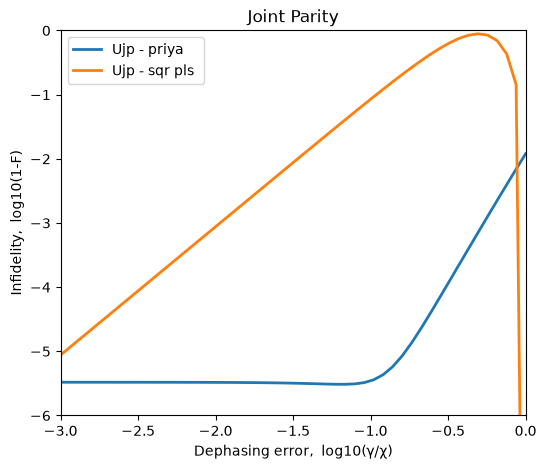

In [10]:
fig = plt.figure(figsize=(6, 5))

ax = fig.add_subplot(111)

ax.plot(np.log10(gamma_over_chi / np.abs(chi)), np.log10( abs(1-fid_Ujp_priya)), linewidth = 2, label = "Ujp - priya ")

ax.plot(np.log10(gamma_over_chi / np.abs(chi)), np.log10( abs(1-fid_Ujp_sqr_pls)), linewidth = 2, label = "Ujp - sqr pls ")

ax.set_xlabel("Dephasing error,  log10(γ/χ)")
ax.set_ylabel("Infidelity,  log10(1-F)")
ax.set_title("Joint Parity")
ax.set_ylim([-6, 0])
ax.set_xlim([-3, 0])
ax.legend();

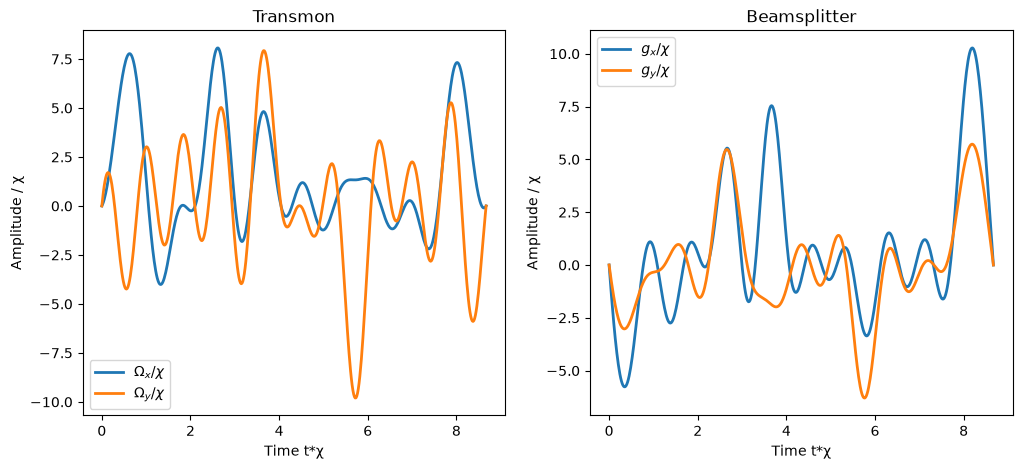

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(t_times_chi, omega_x_over_chi, linewidth = 2, label = r"$\Omega_x/\chi$")
ax1.plot(t_times_chi, omega_y_over_chi, linewidth = 2, label = r"$\Omega_y/\chi$")

ax1.set_xlabel("Time t*χ")
ax1.set_ylabel("Amplitude / χ")
ax1.set_title("Transmon")
ax1.legend();

ax2.plot(t_times_chi, g_x_over_chi, linewidth = 2, label = r"$g_x/\chi$")
ax2.plot(t_times_chi, g_y_over_chi, linewidth = 2, label = r"$g_y/\chi$")

ax2.set_xlabel("Time t*χ")
ax2.set_ylabel("Amplitude / χ")
ax2.set_title("Beamsplitter")
ax2.legend();

Check CZ gate

In [12]:
III = qt.tensor(qt.qeye(N_fock), qt.qeye(N_fock), qt.qeye(2))               # 8x8 identity

# H = (g/2)(a†b + ab†) - (chi/2) n_a Sz + Omega_x/2 Sx + Omega_y/2 Sy + delta/2 Sz
H_priya = [[(a.dag()*b + a*b.dag())/2,          g_x_over_chi],
           [-1j*(a.dag()*b - a*b.dag())/2,      g_y_over_chi],
           [(n_a * Sz)/2,                               -chi],
           [Sx/2,                           omega_x_over_chi],
           [Sy/2,                           omega_y_over_chi]]

H_priya = qt.QobjEvo(H_priya, tlist=t_test)

U_priya = qt.propagator(H_priya, t=t_test, args=None,
                              options={"max_step": 0.1/N_points, "atol": 1e-14, "rtol": 1e-14})

U_priya[-1]

# Ancilla-only rotations: identity on both cavities, rotation on the transmon -- no subspace splitting needed
theta_zz = np.pi/2

X_theta_full = np.cos(theta_zz/2)*III - 1j*np.sin(theta_zz/2)*Sx

Y_pi_4_full       = np.cos(np.pi/4)*III + 1j*np.sin(np.pi/4)*Sy
Y_minus_pi_4_full = np.cos(np.pi/4)*III - 1j*np.sin(np.pi/4)*Sy

# CZ = Y(pi/4) . U_jp . X(theta) . U_jp . Y(-pi/4)
ZZ_L = Y_pi_4_full * U_priya[-1] * X_theta_full * U_priya[-1] * Y_minus_pi_4_full


In [13]:
ZZ_L_sqr_pls = Y_pi_4_full * U_sqr_pls[-1] * X_theta_full * U_sqr_pls[-1] * Y_minus_pi_4_full

ZZ_L_sqr_pls 

Quantum object: dims=[[2, 2, 2], [2, 2, 2]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 7.07106781e-01-7.07106781e-01j  0.00000000e+00-1.11022302e-16j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 2.29934717e-17-1.34015774e-16j  7.07106781e-01+7.07106781e-01j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  -7.07106781e-01-7.07106781e-01j -4.39563496e-17+6.79642728e-15j
  -1.40656251e-11+1.40656251e-11j -2.31265048e-15-8.06265597e-23j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   2.78136414e-17+6.78957652e

In [16]:
noise_points = 50

gamma = np.logspace(-3.,0., noise_points)                                         # noise parameter

gamma_over_chi = gamma * np.abs(chi)

fid_ZZ_priya   = np.zeros_like(gamma)                                        # initialize array for later use
fid_ZZ_sqr_pls = np.zeros_like(gamma)                                        # initialize array for later use

ZZ_L_target = qt.Qobj(block_diag(ZZ_L_sqr_pls[0:2,0:2], -ZZ_L_sqr_pls[2:6,2:6], ZZ_L_sqr_pls[6:8,6:8]))

# Square pulse Ujp -- full 8x8 Fock-space Hamiltonian, same construction as H_full in cell[3]
for q in range(0,noise_points):

    H_priya = [[(a.dag()*b + a*b.dag())/2,          g_x_over_chi],
               [-1j*(a.dag()*b - a*b.dag())/2,      g_y_over_chi],
               [(n_a * Sz)/2,                               -chi],
               [Sx/2,                           omega_x_over_chi],
               [Sy/2,                           omega_y_over_chi],
               [Sz/2,                          gamma_over_chi[q]]]   # add ancilla dephasing noise

    H_priya = qt.QobjEvo(H_priya, tlist=t_test)

    U_priya_noisy = qt.propagator(H_priya, t=t_test, args=None,
                                   options={"max_step": 0.1/N_points, "atol": 1e-14, "rtol": 1e-14})

    ZZ_L_noisy = Y_pi_4_full * U_priya_noisy[-1] * X_theta_full * U_priya_noisy[-1] * Y_minus_pi_4_full

    fid_ZZ_priya[q] = tools.calculate_gate_fidelity(ZZ_L_noisy.full(), ZZ_L_target.full())



    H_square_pulse = (g_chi/2) * (a.dag()*b + a*b.dag()) - (chi/2) * a.dag()*a * Sz + (gamma_over_chi[q]/2) * Sz     # H_full + ancilla dephasing noise

    U_JP_sqr_pls_noisy = qt.propagator(H_square_pulse, t=t_sqr_pls, options={'max_step': 0.5/N_points, 'atol': 1e-14, 'rtol': 1e-14})

    ZZ_L_sqr_pls_noisy = Y_pi_4_full * U_JP_sqr_pls_noisy[-1] * X_theta_full * U_JP_sqr_pls_noisy[-1] * Y_minus_pi_4_full 

    fid_ZZ_sqr_pls[q] = tools.calculate_gate_fidelity(ZZ_L_sqr_pls_noisy.full(), ZZ_L_sqr_pls.full())

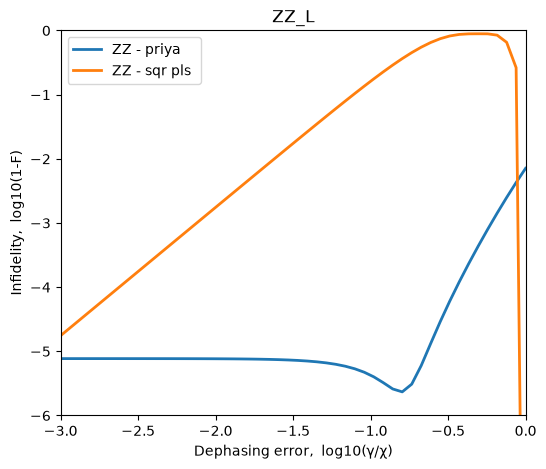

In [20]:
fig = plt.figure(figsize=(6, 5))

ax = fig.add_subplot(111)

ax.plot(np.log10(gamma_over_chi / np.abs(chi)), np.log10( abs(1-fid_ZZ_priya)), linewidth = 2, label = "ZZ - priya ")

ax.plot(np.log10(gamma_over_chi / np.abs(chi)), np.log10( abs(1-fid_ZZ_sqr_pls)), linewidth = 2, label = "ZZ - sqr pls ")

ax.set_xlabel("Dephasing error,  log10(γ/χ)")
ax.set_ylabel("Infidelity,  log10(1-F)")
ax.set_title("ZZ_L")
ax.set_ylim([-6, 0])
ax.set_xlim([-3, 0])
ax.legend();

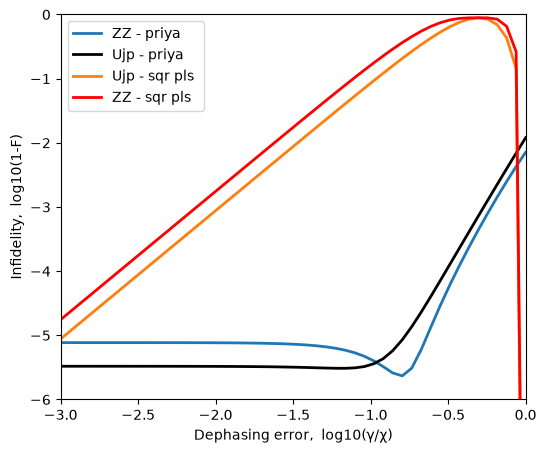

In [19]:
fig = plt.figure(figsize=(6, 5))

ax = fig.add_subplot(111)

ax.plot(np.log10(gamma_over_chi / np.abs(chi)), np.log10( abs(1-fid_ZZ_priya)), linewidth = 2, label = "ZZ - priya ")

ax.plot(np.log10(gamma_over_chi / np.abs(chi)), np.log10( abs(1-fid_Ujp_priya)), color = 'black', linewidth = 2, label = "Ujp - priya ")

ax.plot(np.log10(gamma_over_chi / np.abs(chi)), np.log10( abs(1-fid_Ujp_sqr_pls)), linewidth = 2, label = "Ujp - sqr pls ")

ax.plot(np.log10(gamma_over_chi / np.abs(chi)), np.log10( abs(1-fid_ZZ_sqr_pls)),color = 'red', linewidth = 2, label = "ZZ - sqr pls ")

ax.set_xlabel("Dephasing error,  log10(γ/χ)")
ax.set_ylabel("Infidelity,  log10(1-F)")
ax.set_ylim([-6, 0])
ax.set_xlim([-3, 0])
ax.legend();